<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-01.ipynb#scrollTo=BjN6RhFKSUjI

# Experiment No. 1
## Installing Anaconda, Setting Up the Environment & Linear Regression

---

###  Aim
To set up a Python-based machine learning environment and implement **Simple Linear Regression** from scratch using NumPy — without using any ML libraries like scikit-learn.

---

###  Theory

#### What is Linear Regression?
Linear Regression is one of the most fundamental algorithms in Machine Learning. It is used to model the **relationship between a dependent variable (y)** and one or more **independent variables (X)** by fitting a straight line through the data.

The equation of a simple straight line is:

**ŷ = w·x + b**

Where:
- **ŷ** = predicted output
- **x** = input feature
- **w** = weight (slope of the line)
- **b** = bias (y-intercept)

---

#### How does the model learn?

The model learns by **minimizing the error** between predicted values (ŷ) and actual values (y). This error is measured using a **Cost Function**.

#####  Cost Function — Mean Squared Error (MSE)
MSE measures the average squared difference between actual and predicted values:

**J(w, b) = (1/m) · Σ (ŷᵢ - yᵢ)²**

Where **m** is the number of training examples.

---

#### Gradient Descent
To minimize the cost, we use **Gradient Descent** — an optimization algorithm that iteratively updates weights in the direction that reduces the cost.

Update rules:
- **w = w - α · (∂J/∂w)**
- **b = b - α · (∂J/∂b)**

Where **α (alpha)** is the **learning rate** — a small positive number that controls the step size.

The partial derivatives are:
- **∂J/∂w = (2/m) · Σ (ŷᵢ - yᵢ) · xᵢ**
- **∂J/∂b = (2/m) · Σ (ŷᵢ - yᵢ)**

---

#### Environment Setup Note
In a local setup, we use **Anaconda** to manage Python environments and packages. In Google Colab, the environment is already set up — NumPy, Pandas, and Matplotlib come pre-installed. We just need to import them.

In [ ]:
# Import required libraries
# NumPy - for numerical computations and array operations
import numpy as np

# Pandas - for data handling and creating DataFrames
import pandas as pd

# Matplotlib - for plotting graphs and visualizations
import matplotlib.pyplot as plt

print("All libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


---
###  Step 1: Generate Dataset

We will create a **synthetic (artificial) dataset** to train our Linear Regression model.

The true relationship we will try to learn is:
**y = 3x + 7 + noise**

So the model should ideally learn:
- **w ≈ 3** (slope)
- **b ≈ 7** (intercept)

We add some random **noise** to make the data realistic — in real life, data is never perfectly linear.

In [ ]:
# Set seed for reproducibility — ensures same random data every time
np.random.seed(42)

# Number of data points
m = 100

# Generate input feature x — 100 values between 0 and 10
x = np.linspace(0, 10, m)

# Generate target output y = 3x + 7 + random noise
# np.random.randn(m) gives normally distributed noise
noise = np.random.randn(m) * 2
y = 3 * x + 7 + noise

# Store data in a Pandas DataFrame for easy viewing
data = pd.DataFrame({"x": x, "y": y})

# Display first 5 rows
print("First 5 rows of the dataset:")
print(data.head())
print("\nDataset shape:", data.shape)

First 5 rows of the dataset:
         x          y
0  0.00000   7.993428
1  0.10101   7.026502
2  0.20202   8.901438
3  0.30303  10.955151
4  0.40404   7.743814

Dataset shape: (100, 2)


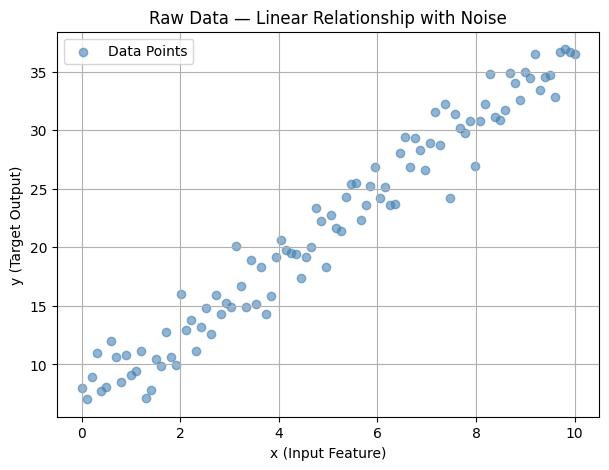

In [ ]:
# Plot the raw data to see its distribution
plt.figure(figsize=(7, 5))

plt.scatter(x, y, color='steelblue', alpha=0.6, label='Data Points')

plt.xlabel("x (Input Feature)")
plt.ylabel("y (Target Output)")
plt.title("Raw Data — Linear Relationship with Noise")
plt.legend()
plt.grid(True)
plt.show()

---
###  Step 2: Train-Test Split

We split our dataset into:
- **Training set (80%)** — used to train/fit the model
- **Test set (20%)** — used to evaluate the model on unseen data

This prevents **overfitting** — where a model performs well on training data but fails on new data.

In [ ]:
# Shuffle and split data into training and test sets
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# 80% training, 20% testing
split = int(0.8 * m)

train = data[:split]
test  = data[split:]

# Extract numpy arrays for computation
X_train = train["x"].values
y_train = train["y"].values

X_test = test["x"].values
y_test = test["y"].values

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 80
Testing samples : 20


---
###  Step 3: Train the Model using Gradient Descent

We initialize the weight **w** and bias **b** to zero.
Then, for each epoch (iteration), we:
1. **Predict** ŷ using current w and b
2. **Compute** the cost (MSE)
3. **Calculate** gradients (partial derivatives)
4. **Update** w and b using the gradient descent rule

This process repeats until the cost stops decreasing significantly (convergence).

In [ ]:
# Initialize parameters
w = 0.0   # weight (slope)
b = 0.0   # bias (intercept)

# Hyperparameters
alpha  = 0.01   # learning rate
epochs = 1000   # number of iterations
tol    = 1e-6   # stopping tolerance

m_train = len(X_train)
cost_history = []

for i in range(epochs):

    # --- Forward Pass: Compute predictions ---
    y_pred = w * X_train + b

    # --- Compute Cost (MSE) ---
    J = (1 / m_train) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(J)

    # --- Compute Gradients ---
    dw = (2 / m_train) * np.sum((y_pred - y_train) * X_train)
    db = (2 / m_train) * np.sum(y_pred - y_train)

    # --- Update Parameters ---
    w = w - alpha * dw
    b = b - alpha * db

    # --- Early Stopping: stop if cost change is very small ---
    if i > 0 and abs(cost_history[i] - cost_history[i-1]) < tol:
        print(f"Converged at epoch {i}")
        break

    # Print cost every 100 epochs
    if i % 100 == 0:
        print(f"Epoch {i:4d} | Cost = {J:.4f} | w = {w:.4f} | b = {b:.4f}")

print(f"\nFinal learned parameters:")
print(f"  w (slope)     = {w:.4f}  (True value = 3)")
print(f"  b (intercept) = {b:.4f}  (True value = 7)")

Epoch    0 | Cost = 547.3483 | w = 2.6363 | b = 0.4337
Epoch  100 | Cost = 6.3548 | w = 3.5838 | b = 3.0568
Epoch  200 | Cost = 4.0618 | w = 3.3586 | b = 4.5333
Epoch  300 | Cost = 3.2097 | w = 3.2213 | b = 5.4333
Epoch  400 | Cost = 2.8931 | w = 3.1376 | b = 5.9819
Epoch  500 | Cost = 2.7755 | w = 3.0866 | b = 6.3163
Epoch  600 | Cost = 2.7318 | w = 3.0555 | b = 6.5202
Epoch  700 | Cost = 2.7156 | w = 3.0365 | b = 6.6444
Epoch  800 | Cost = 2.7095 | w = 3.0250 | b = 6.7202
Epoch  900 | Cost = 2.7073 | w = 3.0179 | b = 6.7663

Final learned parameters:
  w (slope)     = 3.0137  (True value = 3)
  b (intercept) = 6.7942  (True value = 7)


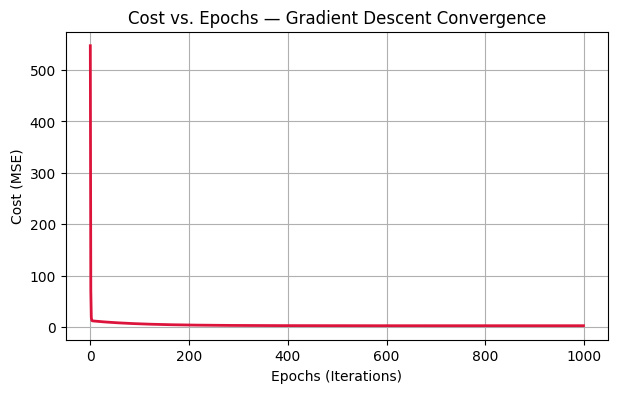

In [ ]:
# Plot cost vs. iterations to see how learning progressed
plt.figure(figsize=(7, 4))

plt.plot(cost_history, color='crimson', linewidth=2)

plt.xlabel("Epochs (Iterations)")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs. Epochs — Gradient Descent Convergence")
plt.grid(True)
plt.show()

---
###  Step 4: Evaluate the Model

We test the model on the **test set** (data it has never seen before).

We use two error metrics:
- **MSE (Mean Squared Error)** — average of squared differences. Penalizes large errors more.
- **MAE (Mean Absolute Error)** — average of absolute differences. More interpretable.

Lower values = better model.

In [ ]:
# Predict on test set
y_test_pred = w * X_test + b

# --- MSE: Mean Squared Error ---
MSE = np.mean((y_test_pred - y_test) ** 2)

# --- MAE: Mean Absolute Error ---
MAE = np.mean(np.abs(y_test_pred - y_test))

print("Model Evaluation on Test Set:")
print(f"  MSE (Mean Squared Error) = {MSE:.4f}")
print(f"  MAE (Mean Absolute Error) = {MAE:.4f}")

Model Evaluation on Test Set:
  MSE (Mean Squared Error) = 5.5052
  MAE (Mean Absolute Error) = 1.9469


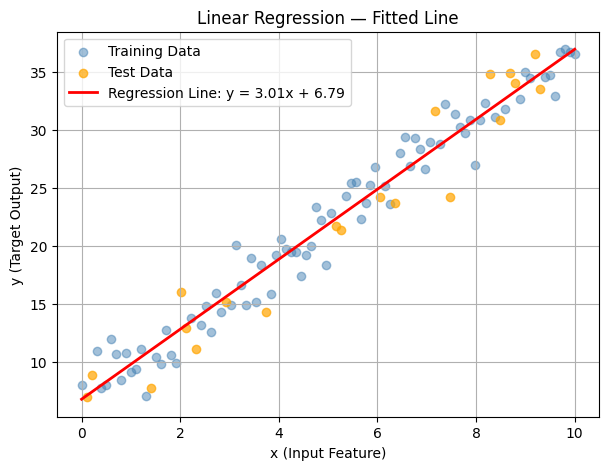

In [ ]:
# Plot training data and the learned regression line
plt.figure(figsize=(7, 5))

# Scatter plot of training data
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, label='Training Data')

# Scatter plot of test data
plt.scatter(X_test, y_test, color='orange', alpha=0.7, label='Test Data')

# Generate regression line points
x_line = np.linspace(0, 10, 200)
y_line = w * x_line + b

# Plot the regression line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regression Line: y = {w:.2f}x + {b:.2f}')

plt.xlabel("x (Input Feature)")
plt.ylabel("y (Target Output)")
plt.title("Linear Regression — Fitted Line")
plt.legend()
plt.grid(True)
plt.show()

---
###  Conclusion

In this experiment, we:
1. Set up the Python environment with NumPy, Pandas, and Matplotlib
2. Generated a synthetic dataset with a known linear relationship
3. Implemented **Simple Linear Regression from scratch** using **Gradient Descent**
4. Trained the model and observed the **cost decrease over epochs**
5. Evaluated the model using **MSE** and **MAE** on the test set

The model successfully learned:
- **w ≈ 3** (true slope = 3)
- **b ≈ 7** (true intercept = 7)

This confirms that gradient descent correctly minimizes the cost function and recovers the true underlying relationship in the data.